__1. Import Libraries__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

__2. Load Dataset__

In [2]:
df = pd.read_csv("Superstore/data/Sample - Superstore.csv", encoding='latin1')

# Preview
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/08/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/08/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


__Basic Information__

In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


__Data Cleaning__

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

__Duplicates__

In [7]:
df.duplicated().sum()

np.int64(0)

__Data Type Conversion__

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

__Feature Engineering__

In [9]:
# Delivery Time
df['Delivery Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# Profit Margin
df['Profit Margin'] = df['Profit'] / df['Sales']

# Discount Category
def discount_category(x):
    if x == 0:
        return 'No Discount'
    elif x <= 0.2:
        return 'Low'
    elif x <= 0.5:
        return 'Medium'
    else:
        return 'High'

df['Discount Category'] = df['Discount'].apply(discount_category)

__EXPLORATORY DATA ANALYSIS__

__Univariate Analysis__

__Sales Distribution__

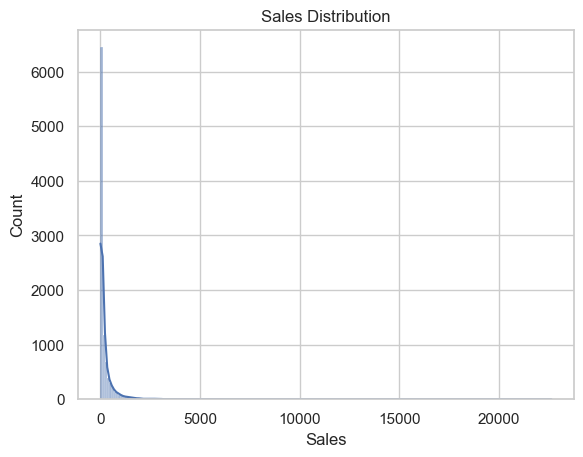

In [10]:
plt.figure()
sns.histplot(df['Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()

__Profit Distribution__

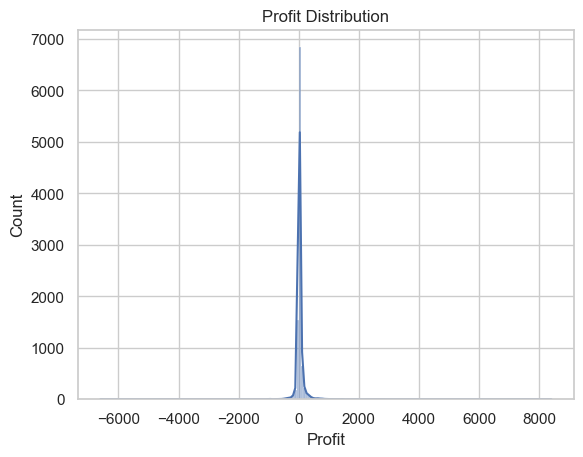

In [11]:
plt.figure()
sns.histplot(df['Profit'], kde=True)
plt.title("Profit Distribution")
plt.show()

__Discount Distribution__

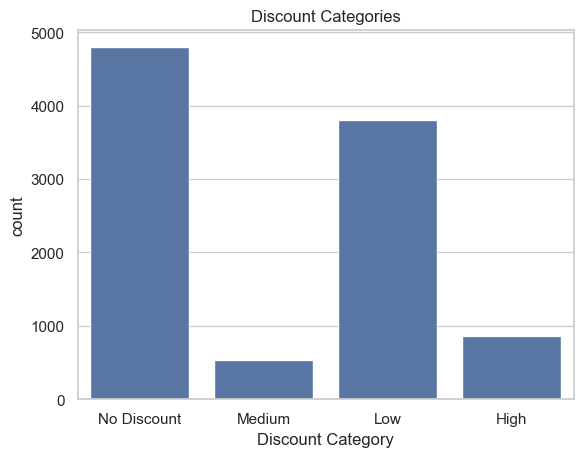

In [12]:
plt.figure()
sns.countplot(x='Discount Category', data=df)
plt.title("Discount Categories")
plt.show()

__Bivariate Analysis__

__Sales vs Profit__

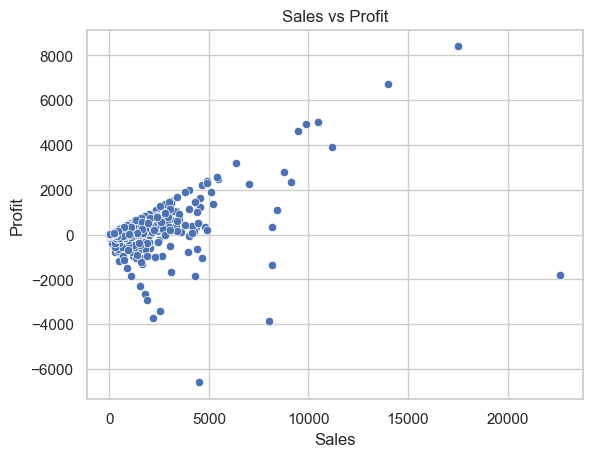

In [13]:
plt.figure()
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()

__Discount vs Profit__

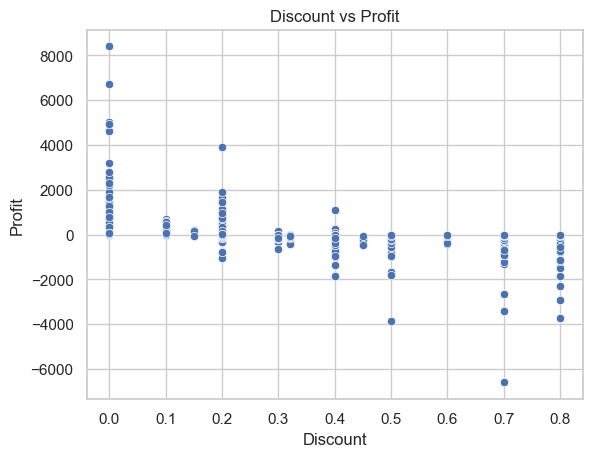

In [14]:
plt.figure()
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

__Category vs Sales__

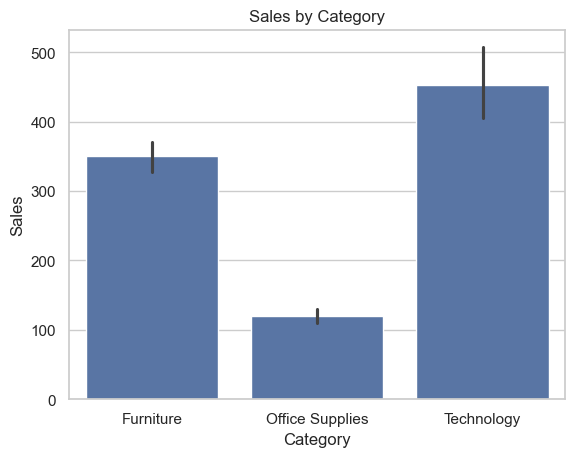

In [15]:
plt.figure()
sns.barplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.show()

__Category vs Profit__

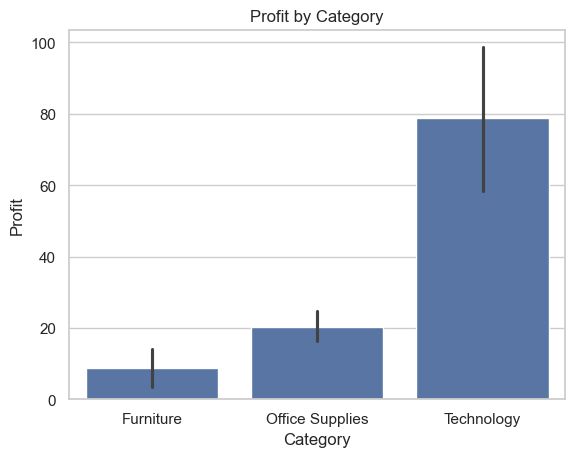

In [16]:
plt.figure()
sns.barplot(x='Category', y='Profit', data=df)
plt.title("Profit by Category")
plt.show()

__Multivariate Analysis__

__Region + Category__

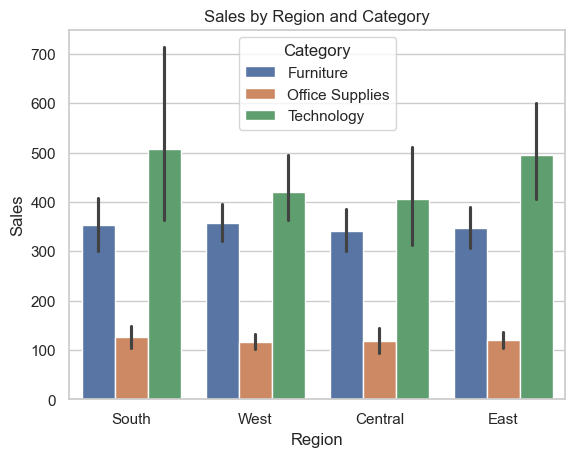

In [17]:
plt.figure()
sns.barplot(x='Region', y='Sales', hue='Category', data=df)
plt.title("Sales by Region and Category")
plt.show()

__Segment Analysis__

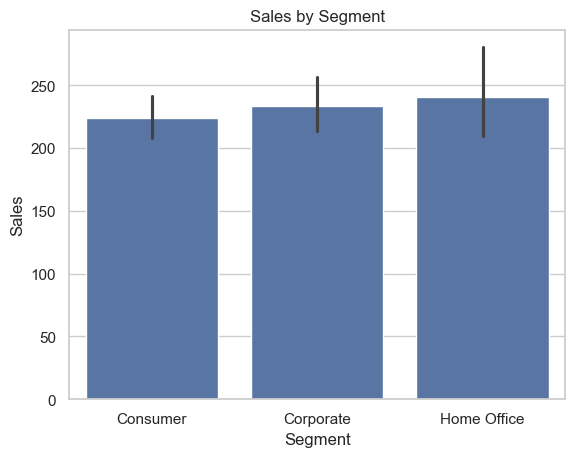

In [18]:
plt.figure()
sns.barplot(x='Segment', y='Sales', data=df)
plt.title("Sales by Segment")
plt.show()

__Time Series Analysis__

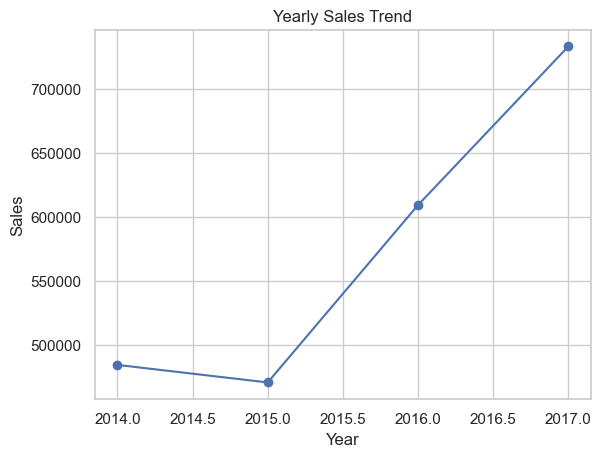

In [19]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

sales_trend = df.groupby('Year')['Sales'].sum()

plt.figure()
sales_trend.plot(marker='o')
plt.title("Yearly Sales Trend")
plt.ylabel("Sales")
plt.show()

__Monthly Trend__

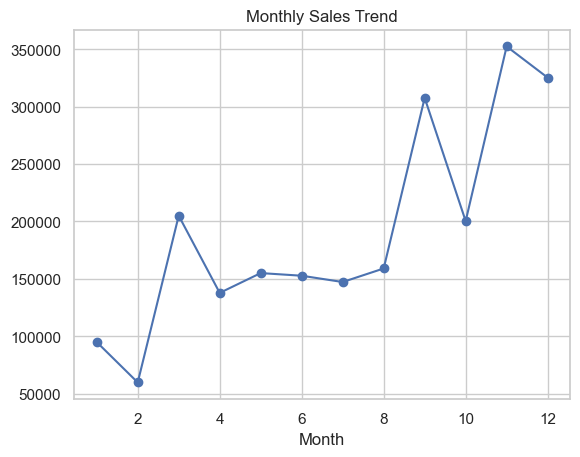

In [20]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure()
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.show()

__Correlation & Heatmap__

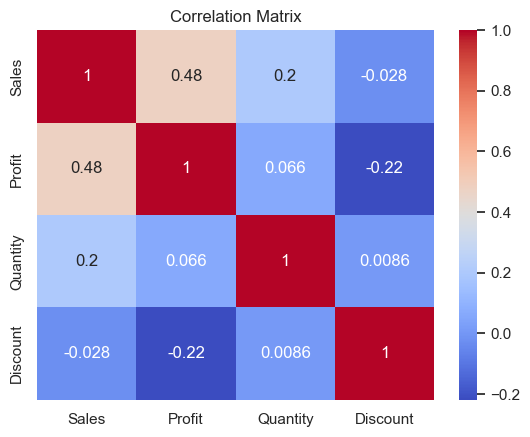

In [21]:
corr = df[['Sales', 'Profit', 'Quantity', 'Discount']].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

__Outlier Detection__

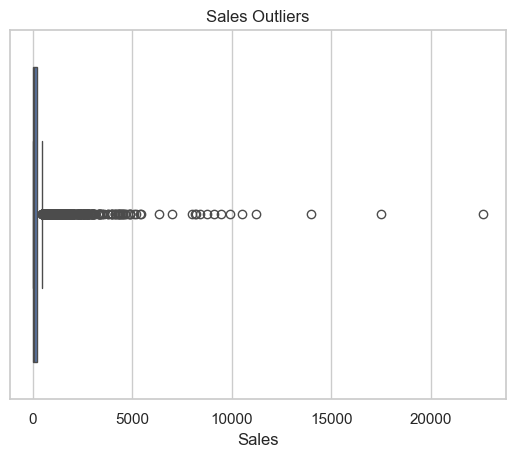

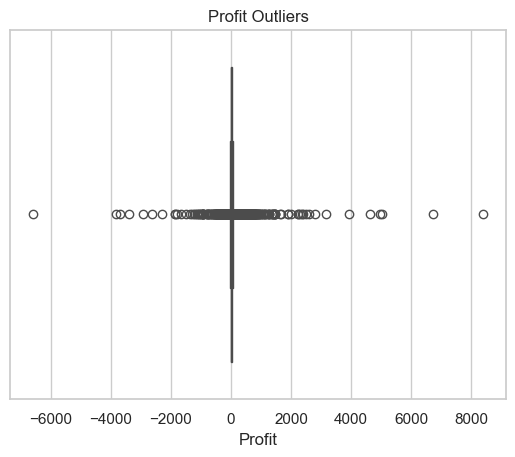

In [22]:
plt.figure()
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

plt.figure()
sns.boxplot(x=df['Profit'])
plt.title("Profit Outliers")
plt.show()

__Top Customers__

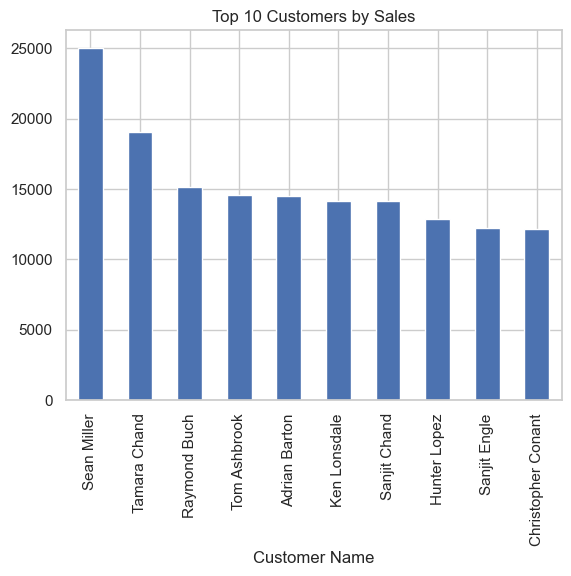

In [23]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Sales")
plt.show()

__Category-wise Profit Margin__

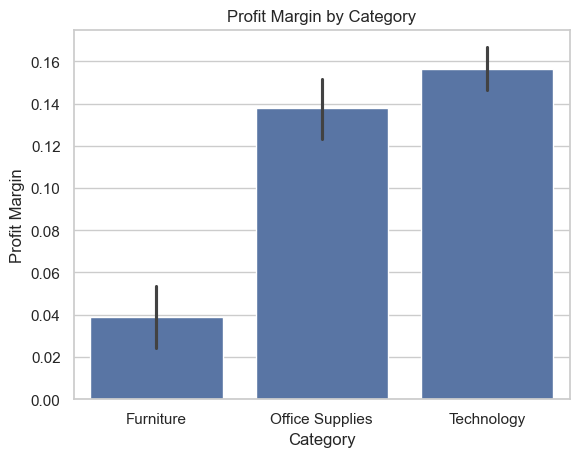

In [24]:
plt.figure()
sns.barplot(x='Category', y='Profit Margin', data=df)
plt.title("Profit Margin by Category")
plt.show()

__Pairplot__

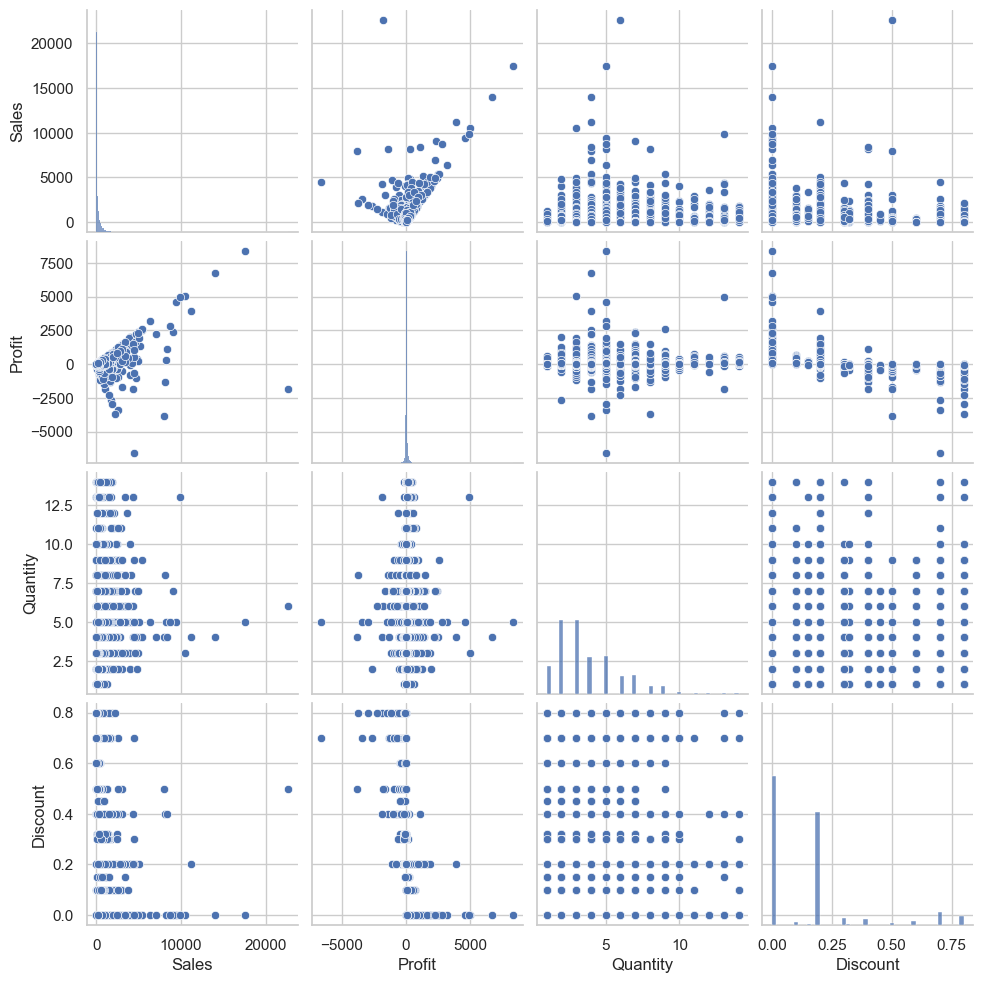

In [25]:
sns.pairplot(df[['Sales', 'Profit', 'Quantity', 'Discount']])
plt.show()